# PyCatan Tutorial 3

In [30]:
from pathlib import Path
import sys
import os
from IPython import get_ipython

# Ensure local `src/` is on sys.path so we can import the package from the notebook
nb_dir = Path().resolve()
sys.path.insert(0, str(nb_dir / ".." / "src"))
sys.path.insert(0, str(nb_dir / "src"))

try:
    import Py_Catan_AI as pc
except Exception as exc:
    raise ImportError(
        "Could not import `Py_Catan_AI`. Make sure the project's `src/` directory is present and dependencies are installed.\n"
        "If you are running the notebook from a different working directory, try setting the notebook's working directory to the repository root."
    ) from exc

# Standard data-science imports
import numpy as np
import pandas as pd
import pickle
import boto3
from dataclasses import dataclass

# IPython helper
ip = get_ipython()

In [31]:
# Set working directory to repo root
os.chdir(pc.get_repo_root(target_name="PyCatan"))

# Determine if running in Jupyter Notebook or as a script and load args accordingly
if get_ipython():
    print("Running in Jupyter Notebook")
    args = pc.Args()
else:
    print("Running as Script")
    args = pc.parse_args()

Running in Jupyter Notebook


# PyCatan Tutorials: Data creation for bootstrapping

This is the PyCatan "data generation for bootstrapping" tutorial — the third in a series of six. It shows how we generate data from the heuristic model. This data is later used to pre-train a model as a starting point for reinforcement learning. The first step is imitation learning, where we train a model to mimic the heuristic player.

The model we train has two outputs: a policy output (a probability distribution over actions) and a value output (a scalar that estimates how good a state is). To train the model we need to generate data containing the policy probabilities and values, linked to state vectors and action masks.

We use the `ValueLoggedCatanPlayer`, which makes decisions using the heuristic value function and also records additional information in an `rl_log`. This log stores the state vector and mask, as well as the action probability distribution and the value estimate. In this tutorial we show how to prepare these probabilities and values for training AI models.

### The tutorials

- Running a game, including generating a game visualization/video with players speaking in character
- Running a tournament
- Data generation for bootstrapping a model
- Model training for bootstrapping reinforcement learning
- Reinforcement learning to train a model
- Running an evaluation tournament to check the performance of a model

### Directory structure

<pre>
PyCatan/
├── docs/ # contains tutorials in Jupyter Notebook format
├── scripts/ # contains scripts to be run command 
├── bootstrap/ # contains data and models used for bootstrapping RL learning
└── src/
    └── Py_Catan_AI/
        ├── models/ # contains the 'default' models used when creating a new instance
        ├── data/ # contains some default data
        └── visuals/ # contains some images used for visualization
</pre>

# Generate data

We want to train a model and need data to do so. This data must contain the state vector and action mask as input, and have as targets a value and a probability distribution over actions. We already have the state vectors and action masks for our heuristic players, but the values and probabilities require more attention. The heuristic player simply checks which action leads to the board state with the highest value (according to the heuristic formula). This player does not account for future returns or values for actions other than the best action.

The `ValueLoggedCatanPlayer` is a heuristic player with the additional feature that it records a probability distribution. We compute this by taking the exponential of the values for each possible action and then normalizing so the probabilities sum to 1. In other words, probabilities are proportional to the exponentials of the action values.

For the value target we look at how the game evolves after taking an action, which we call 'future returns'. We can either use the heuristic value that would be produced later, or use the actual victory points that will be earned. Both approaches are useful; this tutorial demonstrates both.

After generating the data we can still adjust the probabilities and values. How we define them will affect how effective the trained model is as a starting point for reinforcement learning.

## Parameters

In [32]:
print("For this tutorial we use one tournament and meta indicator. To generate a dataset you can" \
      " create a loop and update the indicators to create new file paths.\n")

# to call from command line with parameters, use for example:
# "PyCatan/scripts/PyCatan_tutorial_data_for_bootstrapping_script.py" --tournament-indicators 1 2

tournament_indicator = args.tournament_indicators[0]
print(f"Using tournament indicator: {tournament_indicator}")
meta_indicator = args.meta_indicators[0]
print(f"Using meta indicator: {meta_indicator}")

filename = args.filename_for_bootstrapping_logs.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator))
if args.s3_bucket_name is not None:
    print(f"We will write logs to S3 as {args.s3_bucket_name}{args.directory_on_s3_for_logs}{filename}")
print(f"We will write logs locally to {args.local_directory_for_logs}{filename}")

# check if local directory exists, if not create it
local_dir = Path(args.local_directory_for_logs)
if not local_dir.exists():
    print(f"Creating local directory {local_dir}")
    local_dir.mkdir(parents=True, exist_ok=True)

# check if directory on S3 exists, if not create it
if args.s3_bucket_name is not None:
    s3 = boto3.resource('s3')
    bucket = s3.Bucket(args.s3_bucket_name)
    prefix = args.directory_on_s3_for_logs.lstrip('/')
    objs = list(bucket.objects.filter(Prefix=prefix))
    if len(objs) == 0:
        print(f"Creating directory {prefix} on S3 bucket {args.s3_bucket_name}")
        bucket.put_object(Key=(prefix+'/'))


For this tutorial we use one tournament and meta indicator. To generate a dataset you can create a loop and update the indicators to create new file paths.

Using tournament indicator: 0
Using meta indicator: 0
We will write logs to S3 as pycatanbucketbootstrap/tutorial_meta0_tournament0_rl_log.pkl
We will write logs locally to bootstrap/tutorial_meta0_tournament0_rl_log.pkl


## Datacollection

In [33]:

# -----------------------------------------------------------------------------------
# STEP 0. Set parameters
# -----------------------------------------------------------------------------------
no_games_in_tournament = args.games_per_tournament # increase for larger dataset
gamma = args.gamma # discount factor for future rewards (for bootstrap RL)
tau = args.tau # temperature for sharpening policy probabilities
alpha_heuristic_to_reward = 0  # weight between heuristic-based value and reward-based value for training (1.0 = only heuristic, 0.0 = only reward)
name_of_player_creating_log = "ValueLoggedPlayer"
#"-----------------------------------------------------------------------------------
# STEP 1. Set up players
# -----------------------------------------------------------------------------------
# All 4 players use the ValueBased heuristic so we collect a consistent dataset.
players = [
    pc.ValueLoggedCatanPlayer(pc.default_structure, name=name_of_player_creating_log),
    pc.ValueBasedCatanPlayer(pc.default_structure, name="ValueBased2"),
    pc.ValueBasedCatanPlayer(pc.default_structure, name="ValueBased3"),
    pc.ValueBasedCatanPlayer(pc.default_structure, name="ValueBased4")
]

# -----------------------------------------------------------------------------------
# STEP 2. Run a tournament and collect RL logs
# -----------------------------------------------------------------------------------
# Increase no_games_in_tournament for a larger dataset.
tournament = pc.Tournament(no_games_in_tournament=no_games_in_tournament, verbose=False)

# if we set output_type to 'logs_only', we only get the RL logs back
list_of_rl_logs = tournament.tournament_rl_training_data_generation( players = players, 
                                                            start_game_number=0, 
                                                            stop_game_number=no_games_in_tournament, 
                                                            fixed_player_order=False,
                                                            output_type = 'logs_only')
print(f"✅ Collected {len(list_of_rl_logs)} RL log entries from {tournament.no_games_in_tournament} games")
rl_log = pd.concat(list_of_rl_logs, ignore_index=True)

# -----------------------------------------------------------------------------------
# STEP 3. Update RL log 
# -----------------------------------------------------------------------------------
# === add tournament index and meta index
rl_log["tournament_indicator"] = tournament_indicator
rl_log["meta_indicator"] = meta_indicator

# -----------------------------------------------------------------------------------
# STEP 4. Save dataset to Pickle
# -----------------------------------------------------------------------------------
save_path = f"{args.local_directory_for_logs}"+filename.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator))
with open(save_path, "wb") as f:
    pickle.dump(rl_log , f)

print(f"✅ Raw logs for tournament saved to {save_path}")

# -----------------------------------------------------------------------------------
# STEP 5. Upload to S3 (optional)
# -----------------------------------------------------------------------------------
if args.s3_bucket_name is not None:
    s3_path = f"{args.directory_on_s3_for_logs}"+filename.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator))
    s3 = boto3.client("s3")
    s3.upload_file(save_path, args.s3_bucket_name, s3_path)
    print(f"✅ Uploaded logs to s3://{args.s3_bucket_name}/{s3_path}")


✅ Collected 4 RL log entries from 4 games
✅ Raw logs for tournament saved to bootstrap/tutorial_meta0_tournament0_rl_log.pkl
✅ Uploaded logs to s3://pycatanbucket/bootstrap/tutorial_meta0_tournament0_rl_log.pkl


## Update the training data for the value head (the critic)

To prepare targets for the value head (the critic) we evaluate each game from the perspective of the player and estimate the expected future returns for every state. These future returns can be computed either from the heuristic value function — which produces a smoother, more gradual signal that is often easier to train on — or from the actual victory points earned, which provides an objective, model‑agnostic return. The helper function `finalize_rewards_on_single_game_rl_log` supports both approaches, so you can choose the heuristic return for more stable training or the victory‑point return when you need an unbiased reinforcement‑learning target.

Below you see for a few games how both value metrics evolve over the course of the game.

In [34]:

# === update per game future discounted rewards (based on gamma discount factor and earned victory points).
# we also write delta_reward and advantage for each entry based on state_value as populated during this phase
unique_meta_ids = rl_log["meta_indicator"].unique()
for meta_id in unique_meta_ids:
    unique_tournament_ids = rl_log[rl_log["meta_indicator"] == meta_id]["tournament_indicator"].unique()
    for tournament_id in unique_tournament_ids:
        unique_game_ids = rl_log[(rl_log["meta_indicator"] == meta_id) & (rl_log["tournament_indicator"] == tournament_id)]["game_indicator"].unique()
        for game_id in unique_game_ids:
            log_mask = (rl_log["meta_indicator"] == meta_id) & (rl_log["tournament_indicator"] == tournament_id) & (rl_log["game_indicator"] == game_id)

            updated = pc.finalize_rewards_on_single_game_rl_log(rl_log.loc[log_mask], gamma=gamma)
            rl_log.loc[log_mask, ["delta_reward", "return", "advantage"]] = updated[["delta_reward", "return", "advantage"]]

# === Determine value for training
# === We can build in a gradual transition from purely heuristic-based values to purely reward-based values over multiple meta iterations.
alpha = np.square(alpha_heuristic_to_reward)
beta = 1.0 - alpha
# For now, we use only heuristic-based values.
rl_log["value_for_training"] = alpha*rl_log["scaled_heuristic_return"].copy() + beta*rl_log["return"].copy()



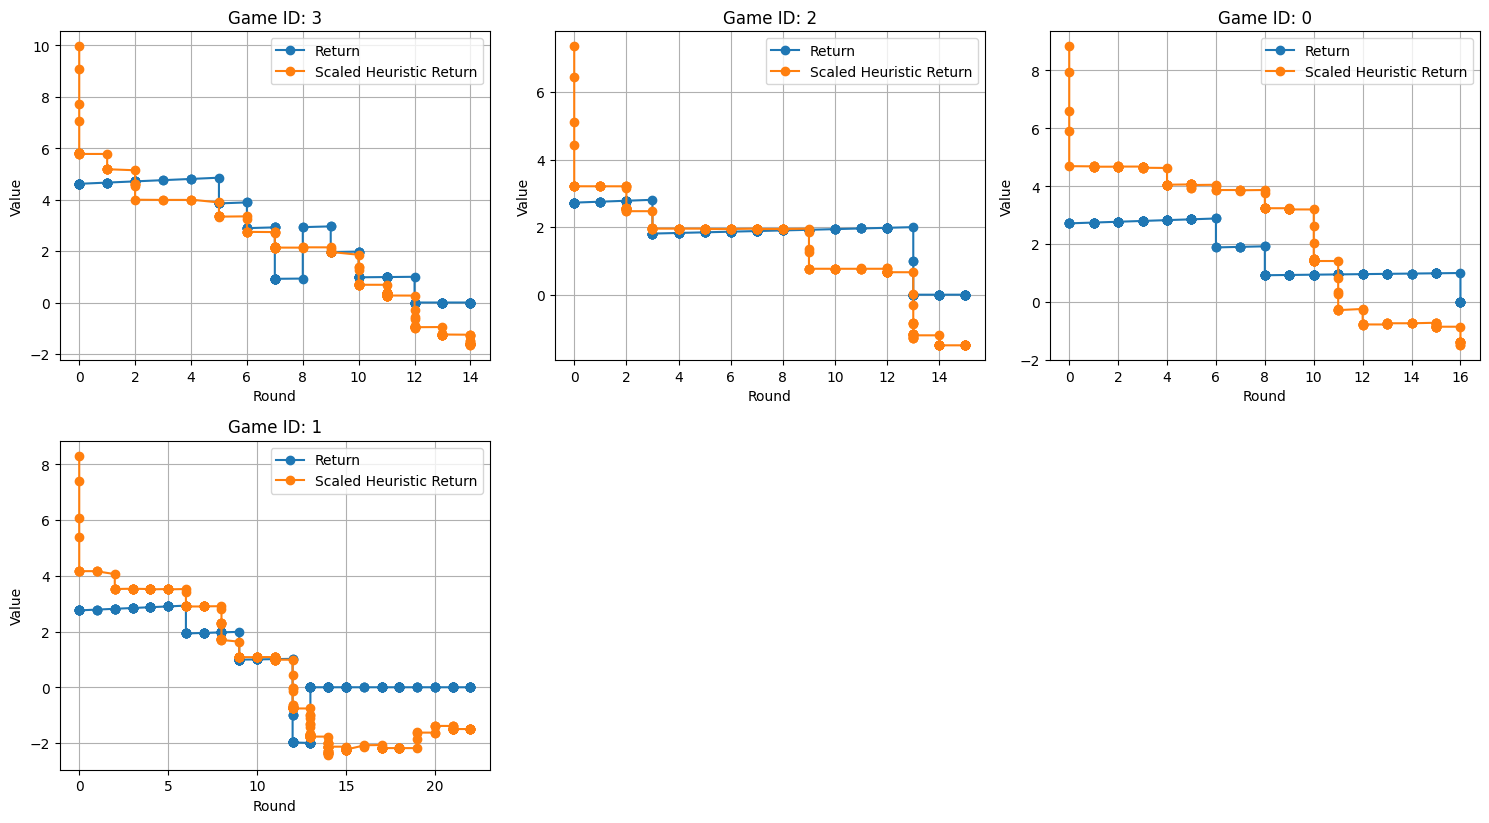

In [35]:
# Plot multiple random games: 3x3 grid (up to 9 games)
import matplotlib.pyplot as plt
import random
import numpy as np

# Select up to 9 unique random game IDs
unique_game_ids = list(rl_log["game_indicator"].unique())
num_to_plot = min(9, len(unique_game_ids))
selected_game_ids = random.sample(unique_game_ids, num_to_plot)

# Create 3x3 grid
ncols = 3
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), squeeze=False)
axes_flat = axes.flatten()

for i, gid in enumerate(selected_game_ids):
    ax = axes_flat[i]
    game_log = rl_log[rl_log["game_indicator"] == gid].sort_values(by="round")
    if game_log.empty:
        ax.set_visible(False)
        continue

    x = game_log["round"].to_numpy()
    y_return = game_log["return"].to_numpy()
    y_heur = game_log["scaled_heuristic_return"].to_numpy()

    ax.plot(x, y_return, label="Return", marker='o')
    ax.plot(x, y_heur, label="Scaled Heuristic Return", marker='o')
    ax.set_title(f"Game ID: {gid}")
    ax.set_xlabel("Round")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True)

# Hide any unused subplots
for j in range(num_to_plot, nrows * ncols):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()


## Generate the training data for the policy head (the actor)

The `ValueLoggedCatanPlayer` produces a probability distribution over actions from their heuristic values. For each possible action it evaluates the resulting board state and assigns a score; the probabilities are proportional to the exponentials of these scores and then normalized so they sum to 1. To create training targets we may want to "sharpen" these distributions — below are two helper functions that implement fixed-value sharpening and temperature-based sharpening to modify the probability mass in a controlled way.

Below you see the effect of sharpening on the action space. We also plotted a pareto of highest probabilities where the sharpening is more visible.

In [36]:
def sharpen_policy_probs_on_log_with_fixed_values(rl_log: pd.DataFrame) -> pd.DataFrame:
    """
    Given a DataFrame with a "policy_probs" column (list of floats),
    create a new column "policy_for_training" where only the top 1, 2, or 3
    probabilities are kept, adjusted to sum to 1.0, and the rest set to 0.

    We set the probabilities as follows:
    - If there is only 1 action, its probability is set to 1.0
    - If there are 2 actions, the top action is set to 0.9 and the second to 0.1
    - If there are 3 or more actions, the top action is set to 0.9, 
        the second to 0.09, and the third to 0.01

    Args:
        df (pd.DataFrame): Input DataFrame with "policy_probs" column.
    Returns:
        pd.DataFrame: DataFrame with added "policy_for_training" column.
    """

    probs_tpl = {1: [1.0], 2: [0.9, 0.1], 3: [0.9, 0.09, 0.01]}
    if not isinstance(rl_log, pd.DataFrame):
        raise ValueError("rl_log must be a pandas DataFrame")
    # (optional) assert single game here if you need it
    rl_log_out = rl_log.copy()

    for idx in rl_log_out.index:
        p = np.asarray(rl_log_out.at[idx, "policy_probs"], dtype=np.float32)

        # normalize defensively
        s = p.sum()
        if not np.isfinite(s) or s <= 0:
            p = np.full_like(p, 1.0 / len(p))
        else:
            p = p / s

        # pick top-1/2/3 by value
        order = np.argsort(p)[::-1]           # descending
        k = min(3, len(order))
        adj = np.zeros_like(p)
        weights = probs_tpl[k]
        for i in range(k):
            adj[order[i]] = weights[i]

        rl_log_out.at[idx, "policy_for_training"] = adj.tolist()

    return rl_log_out

def sharpen_policy_probs_based_on_temperature(rl_log: pd.DataFrame, tau: float = 0.5, eps: float = 1e-8) -> pd.DataFrame:
    """
    Gradually sharpen a probability distribution using temperature scaling.
    
    Args:
        probs: np.ndarray, original probability distribution (not necessarily normalized).
        tau: float, temperature parameter.
             tau=1 -> no change, tau<1 -> sharper, tau>1 -> flatter.
        eps: small constant for numerical stability.
    
    Returns:
        Sharpened probability distribution (same shape, sums to 1).
    """
    def sharpen_probs_temperature(probs: np.ndarray, tau: float = 0.5, eps: float = 1e-8) -> np.ndarray:
        # first normalize
        p = np.asarray(probs, dtype=np.float32)
        p = np.maximum(p, eps)
        p /= p.sum()

        # apply log/temperature
        log_p = np.log(p + eps) / tau
        exp_p = np.exp(log_p - np.max(log_p))  # subtract max for numerical stability
        p_sharp = exp_p / exp_p.sum()

        return p_sharp
    
    rl_log_out = rl_log.copy()
    rl_log_out["policy_for_training"] = rl_log_out["policy_probs"].apply(lambda p: sharpen_probs_temperature(np.array(p), tau,eps))
    return rl_log_out

In [37]:

# === populate policy probs, only top 3 actions get 90%, 10% or 1% probbility, rest zero
# result is written to entry['policy_for_training']
rl_log = sharpen_policy_probs_on_log_with_fixed_values(rl_log)



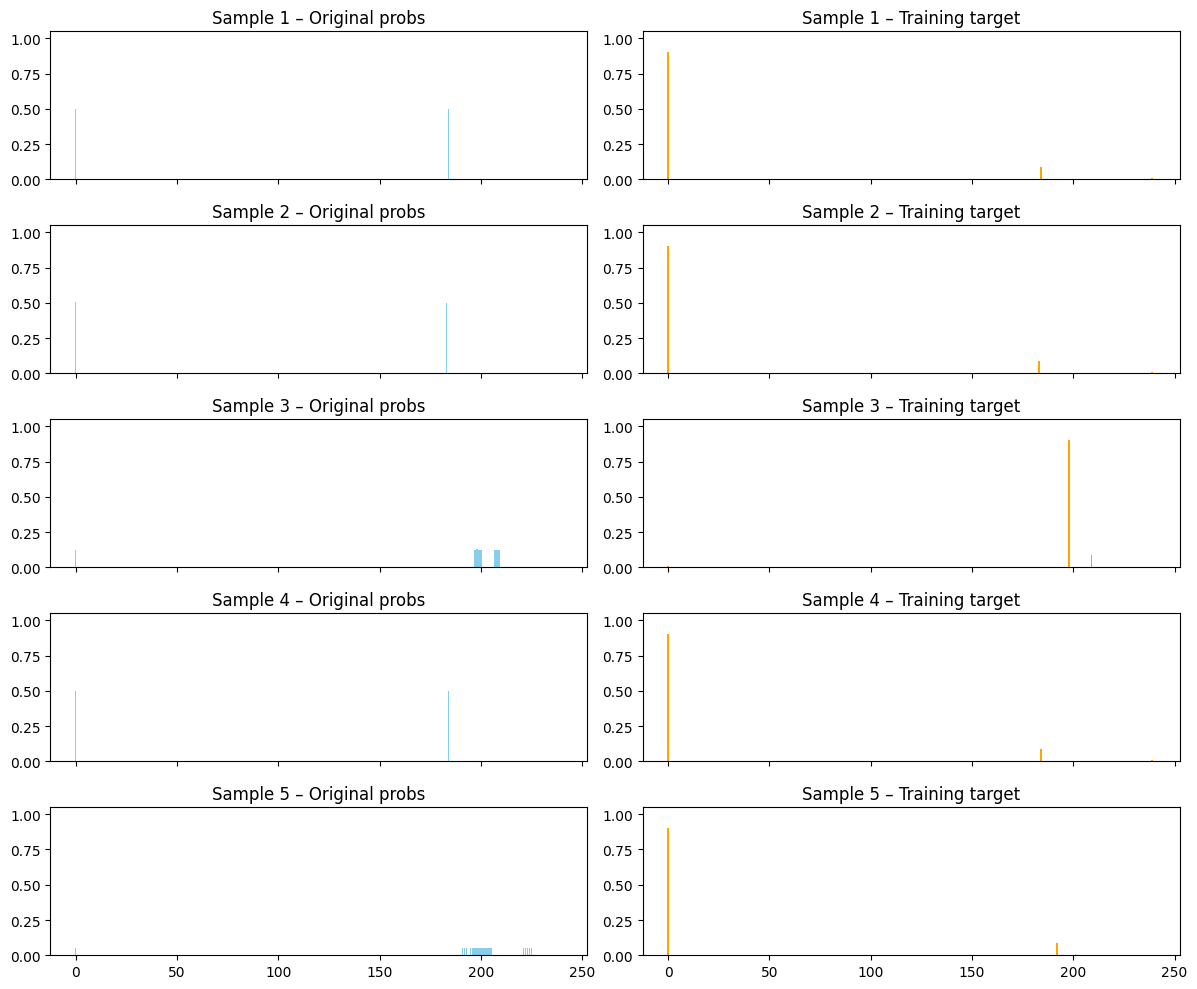

In [38]:
# Pick a few random samples
n_samples = 5
sample_idx = np.random.choice(len(rl_log), size=n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 2, figsize=(12, 2 * n_samples), sharex=True)

for i, idx in enumerate(sample_idx):
    orig = np.array(rl_log.loc[idx, "policy_probs"], dtype=np.float32)
    new = np.array(rl_log.loc[idx, "policy_for_training"], dtype=np.float32)

    axes[i, 0].bar(np.arange(len(orig)), orig, color="skyblue")
    axes[i, 0].set_title(f"Sample {i+1} – Original probs")
    axes[i, 1].bar(np.arange(len(new)), new, color="orange")
    axes[i, 1].set_title(f"Sample {i+1} – Training target")

    # zoom y-axis a bit so small differences are visible
    for ax in axes[i]:
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [39]:
# === populate policy probs, only top 3 actions get 90%, 10% or 1% probbility, rest zero
# result is written to entry['policy_for_training']
rl_log = sharpen_policy_probs_based_on_temperature(rl_log, tau=tau, eps=1e-8)


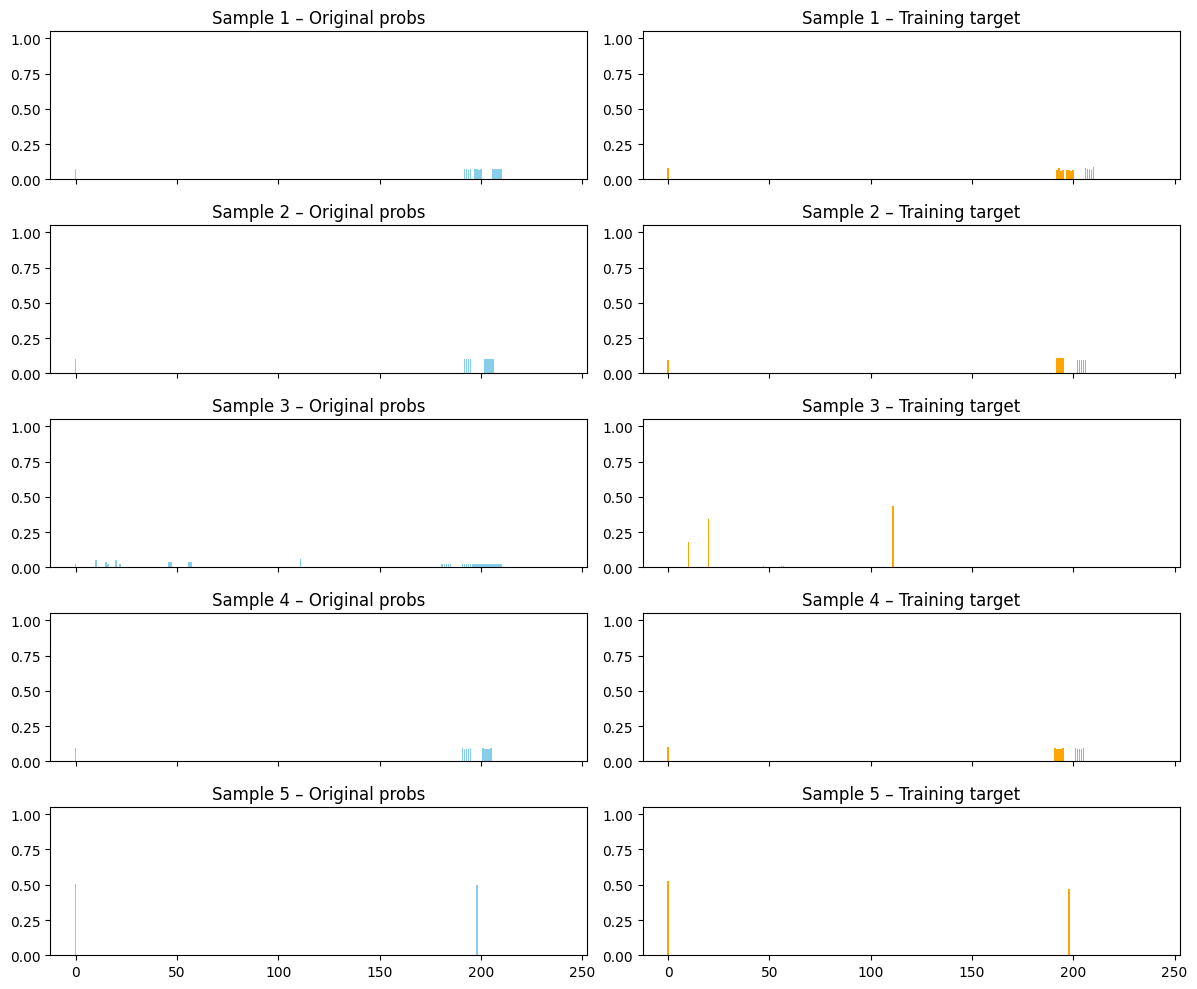

In [40]:
# Pick a few random samples
n_samples = 5
sample_idx = np.random.choice(len(rl_log), size=n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 2, figsize=(12, 2 * n_samples), sharex=True)

for i, idx in enumerate(sample_idx):
    orig = np.array(rl_log.loc[idx, "policy_probs"], dtype=np.float32)
    new = np.array(rl_log.loc[idx, "policy_for_training"], dtype=np.float32)

    axes[i, 0].bar(np.arange(len(orig)), orig, color="skyblue")
    axes[i, 0].set_title(f"Sample {i+1} – Original probs")
    axes[i, 1].bar(np.arange(len(new)), new, color="orange")
    axes[i, 1].set_title(f"Sample {i+1} – Training target")

    # zoom y-axis a bit so small differences are visible
    for ax in axes[i]:
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

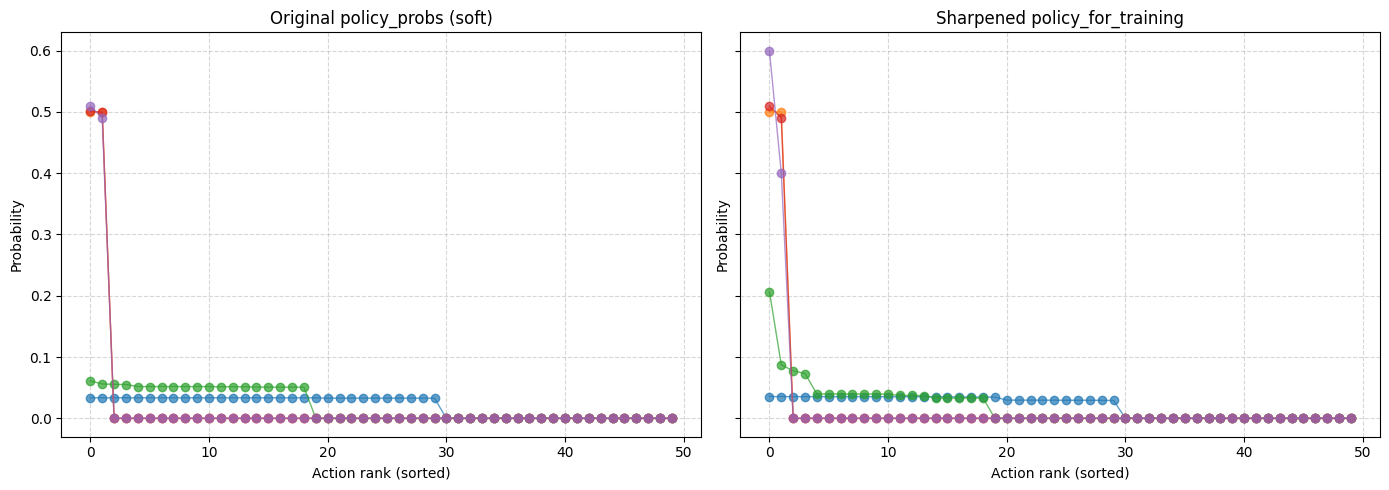

In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pareto_comparison(df, n_samples=5):
    """
    Compare Pareto-style curves for original vs sharpened distributions.
    Shows how sharpening changes the probability drop-off.
    """
    idxs = np.random.choice(len(df), size=n_samples, replace=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for idx in idxs:
        # --- original ---
        p_orig = np.array(df.loc[idx, "policy_probs"], dtype=np.float32)
        p_orig = np.maximum(p_orig, 1e-8); p_orig /= p_orig.sum()
        sorted_orig = np.sort(p_orig)[::-1]
        axes[0].plot(sorted_orig[:50], marker="o", linewidth=1, alpha=0.7, label=f"Sample {idx}")

        # --- sharpened ---
        p_new = np.array(df.loc[idx, "policy_for_training"], dtype=np.float32)
        p_new = np.maximum(p_new, 1e-8); p_new /= p_new.sum()
        sorted_new = np.sort(p_new)[::-1]
        axes[1].plot(sorted_new[:50], marker="o", linewidth=1, alpha=0.7, label=f"Sample {idx}")

    axes[0].set_title("Original policy_probs (soft)")
    axes[1].set_title("Sharpened policy_for_training")

    for ax in axes:
        ax.set_xlabel("Action rank (sorted)")
        ax.set_ylabel("Probability")
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_pareto_comparison(rl_log, n_samples=5)

# Perform checks on the log

We perform some basic checks on the log to ensure it is consistent.

In [42]:

# === Check action masks are correct for state vectors (except for trade_player actions)
# trade_player actions depend on history of rejected trades, so we skip those checks here.
for index,entry in rl_log.iterrows():
    state_vector = entry['state']
    action_mask = entry['mask']
    if entry['phase'] == "gameplay":
        calc_mask = pc.mask_from_vector(structure = pc.default_structure, vector = state_vector)
        # check if the masks differ for any index that is not a trade_player action
        for i in range(len(action_mask)):
            if pc.default_structure.trade_player_actions[i] == 1:
                continue
            if action_mask[i] != calc_mask[i]:
                print(f"Action mask: {action_mask}")
                print(f"Calculated mask: {calc_mask}")
                raise ValueError(f"Index {index}: Action mask does not match state at index {index} for non-trade_player action")
        
    elif entry['phase'] == "trade":
        assert sum(action_mask) > 0, f"Index {index}: Action mask has no legal actions for trade phase"
        assert int(sum(action_mask)) <= 2, f"Index {index}: Action mask has multiple legal actions for trade phase"
        if sum(action_mask) == 1:
            assert action_mask[0] == 1, f"Index {index}: Only action in trade phase must be 'no trade' action"
        if sum(action_mask) == 2:
            assert action_mask[0] == 1, f"Index {index}: 'no trade' action must be legal in trade phase"
            action_index = np.nonzero(action_mask)[0][1]
            # ('trade_player', (give, get)): Player trade action
            type, (give, get) = pc.default_structure.index_to_action(action_index)
            assert type == 'trade_player', f"Index {index}: Action index {action_index} must be a trade_player action"
            hand = state_vector[pc.default_structure.vector_indices['hand_for_player'][0]]
            assert hand[give] > 0, f"Index {index}: Illegal trade action, player does not have resource to give"
    elif entry['phase'] == "setup":
        village_mask = pc.mask_from_vector_for_building_village(structure = pc.default_structure, vector = state_vector)
        if np.array_equal(village_mask, action_mask):
            pass
        else:
            for node_index, node_value in enumerate(state_vector[pc.default_structure.vector_indices['nodes']]):
                if node_value == 1:
                    village_action = pc.default_structure.action_to_index(('village', node_index))
                    street_mask = pc.mask_from_vector_for_building_street(structure = pc.default_structure, 
                                                                        vector = state_vector,
                                                                        action_index = village_action)
                    if np.array_equal(street_mask, action_mask):
                        break
            else:
                raise ValueError(f"Index {index}: Action mask does not match state at index {index} for building village or street")


for index, row in rl_log.iterrows():
    action_mask = row["mask"] 
    assert action_mask[row["best_action"]] == 1, f"Best action is illegal at index {index}"
    assert action_mask[row["action"]] == 1, f"Taken action is illegal at index {index}"
    # === Check all action with non-zero probability are legal
    non_zero_indices = np.nonzero(row["policy_probs"])[0]
    assert np.all(action_mask[non_zero_indices] == 1), f"Non-zero policy probabilities for illegal actions at index {index}"
    assert np.isclose(np.sum(row["policy_probs"]), 1.0), f"Policy probabilities do not sum to 1 at index {index}"
    if row['phase'] == "trade" and not np.isclose(row["policy_probs"][non_zero_indices[0]], row["policy_probs"][non_zero_indices[1]]):
        # === Check best action is action taken and legal
        best_action = int(np.argmax(row["policy_probs"]))
        assert action_mask[best_action] == 1, f"Best action is illegal at index {index}"
        assert best_action == row["action"], f"Best action does not match taken action at index {index}: {best_action} vs {row['action']}"
        assert best_action == row["best_action"], f"Best action from policydoes not match best action at index {index} : {best_action} vs {row['best_action']}"
    if row['phase'] == "setup":
        assert action_mask[0] == 0, f"No 'no action' allowed in setup phase at index {index}"
        # === Check best action is action taken and legal
        best_action = int(np.argmax(row["policy_probs"]))
        assert action_mask[best_action] == 1, f"Best action is illegal at index {index}"
        assert best_action == row["action"], f"Best action does not match taken action at index {index}: {best_action} vs {row['action']}"
        assert best_action == row["best_action"], f"Best action from policydoes not match best action at index {index} : {best_action} vs {row['best_action']}"

# === Check every game as unique idea (for unique meta index, tournament index and game index)
unique_meta_ids = rl_log["meta_indicator"].unique()
for meta_id in unique_meta_ids:
    unique_tournament_ids = rl_log[rl_log["meta_indicator"] == meta_id]["tournament_indicator"].unique()
    for tournament_id in unique_tournament_ids:
        unique_game_ids = rl_log[(rl_log["meta_indicator"] == meta_id) & (rl_log["tournament_indicator"] == tournament_id)]["game_indicator"].unique()
        for game_id in unique_game_ids:
            log_mask = (rl_log["meta_indicator"] == meta_id) & (rl_log["tournament_indicator"] == tournament_id) & (rl_log["game_indicator"] == game_id)
            entries = rl_log[log_mask]
            assert len(entries) > 0, f"No entries found for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            unique_game_ids_in_entries = entries["game_indicator"].unique()
            assert len(unique_game_ids_in_entries) == 1, f"Multiple game IDs found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            # check all entries for game have same meta_indicator, tournament_indicator, game_indicator, player, final_ranking, final_victory_points
            unique_meta_ids_in_entries = entries["meta_indicator"].unique()
            assert len(unique_meta_ids_in_entries) == 1 and unique_meta_ids_in_entries[0] == meta_id, f"Multiple or incorrect meta IDs found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            unique_tournament_ids_in_entries = entries["tournament_indicator"].unique()
            assert len(unique_tournament_ids_in_entries) == 1 and unique_tournament_ids_in_entries[0] == tournament_id, f"Multiple or incorrect tournament IDs found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            unique_game_ids_in_entries = entries["game_indicator"].unique()
            assert len(unique_game_ids_in_entries) == 1 and unique_game_ids_in_entries[0] == game_id, f"Multiple or incorrect game IDs found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            unique_players_in_entries = entries["player"].unique()
            assert len(unique_players_in_entries) == 1 and unique_players_in_entries[0] == name_of_player_creating_log, f"Multiple or incorrect player names found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            unique_final_rankings_in_entries = entries["final_ranking"].unique()
            assert len(unique_final_rankings_in_entries) == 1, f"Multiple final rankings found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
            unique_final_victory_points_in_entries = entries["final_victory_points"].unique()
            assert len(unique_final_victory_points_in_entries) == 1, f"Multiple final victory points found in entries for game {game_id} in tournament {tournament_id}, meta {meta_id}"
# === Check player name in RL Log is always correct
assert np.all(rl_log["player"] == name_of_player_creating_log), "Player name in RL log does not match expected name"


# Save the logs with probabilities and value data ready for training

In [43]:
# -----------------------------------------------------------------------------------
# STEP 4. Save dataset to Pickle
# -----------------------------------------------------------------------------------
save_path = f"{args.local_directory_for_logs}"+filename.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator))
with open(save_path, "wb") as f:
    pickle.dump(rl_log , f)

print(f"✅ Raw logs for tournament saved to {save_path}")

# -----------------------------------------------------------------------------------
# STEP 5. Upload to S3 (optional)
# -----------------------------------------------------------------------------------
if args.s3_bucket_name is not None:
    s3_path = f"{args.directory_on_s3_for_logs}"+filename.replace('tournament_indicator', str(tournament_indicator)).replace('meta_indicator', str(meta_indicator))
    s3 = boto3.client("s3")
    s3.upload_file(save_path, args.s3_bucket_name, s3_path)
    print(f"✅ Uploaded logs to s3://{args.s3_bucket_name}/{s3_path}")

✅ Raw logs for tournament saved to bootstrap/tutorial_meta0_tournament0_rl_log.pkl
✅ Uploaded logs to s3://pycatanbucket/bootstrap/tutorial_meta0_tournament0_rl_log.pkl
